# Case Study

## 1. API request

In [202]:
import requests
import time
import pandas as pd
from   datetime import datetime
import numpy as np
import pytz
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from   matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
from itertools import product

If we want to get the data directly from an API server this is the fetch function. However due to easibility of submission I included the csv file for the intraday data and the RSI index, so the code can run more easily.

In [ ]:
API_KEY = 'YOUR_POLYGON_API_KEY'

def fetch_polygon_data(ticker, start, end, period, enforce_rate_limit=True):
    url = f'https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/{period}/{start}/{end}?adjusted=false&sort=asc&limit=50000&apiKey={API_KEY}'
    data_list = []
    req_count, start_time = 0, time.time()

    while url:
        # Handle Rate Limiting
        if enforce_rate_limit and req_count == 5:
            elapsed = time.time() - start_time
            if elapsed < 60: 
                time.sleep(60 - elapsed)
            req_count, start_time = 0, time.time()

        # Fetch Data
        res = requests.get(url).json()
        if 'error' in res or res.get('status') != 'OK': 
            break
        
        data_list.extend(res.get('results', []))
        req_count += 1
        
        # Handle Pagination
        url = res.get('next_url')
        if url: 
            url += f'&apiKey={API_KEY}'

    if not data_list: 
        return pd.DataFrame()

    # Data procession
    df = pd.DataFrame(data_list).rename(columns={'v': 'volume', 'o': 'open', 'h': 'high', 'l': 'low', 'c': 'close'})
    
    # Converting the timestamp to the right timezone and filtering for market hours
    df['caldt'] = pd.to_datetime(df['t'], unit='ms', utc=True).dt.tz_convert('America/New_York').dt.tz_localize(None)
    
    if period == 'minute':
        df = df.set_index('caldt').between_time('09:30', '15:59').reset_index()

    return df[['volume', 'open', 'high', 'low', 'close', 'caldt']]

## 2. Build the data frame

In [204]:
ticker    = 'SPY'
from_date = '2023-04-10'
until_date = '2024-12-30'

#If we want to use the API, uncomment the line below and comment out the CSV loading line.

# df = fetch_polygon_data(ticker, from_date, until_date, 'minute')

df = pd.read_csv('spy_intraday.csv')

df['caldt'] = pd.to_datetime(df['caldt'])
df = df.set_index('caldt')

# For API data, we need to derive the 'day' column from the timestamp index. For CSV data, it's already done.
# df['day'] = pd.to_datetime(df.index).date

#Group by day for easier daily calculations
daily_groups = df.groupby('day')

#Get list of all unique days, so we can loop through them to calculate daily metrics
all_days     = df['day'].unique()


#New rows for intraday metrics (initialized with NaN)
df['move_open'] = np.nan
df['vwap']      = np.nan
df['spy_dvol']  = np.nan


#Create  a series to hold spy returns
spy_ret = pd.Series(index=all_days, dtype=float)


# Derive all daily metrics from intraday data
for d in range(1, len(all_days)):
    current_day      = all_days[d]
    prev_day         = all_days[d - 1]
    current_day_data = daily_groups.get_group(current_day)
    prev_day_data    = daily_groups.get_group(prev_day)

    # VWAP
    hlc = (current_day_data['high'] + current_day_data['low'] + current_day_data['close']) / 3
    cum_vol_x_hlc = (current_day_data['volume'] * hlc).cumsum()
    cum_volume = current_day_data['volume'].cumsum()
    df.loc[current_day_data.index, 'vwap'] = cum_vol_x_hlc / cum_volume

    # Absolute move from open
    open_price = current_day_data['open'].iloc[0]
    df.loc[current_day_data.index, 'move_open'] = (current_day_data['close'] / open_price - 1).abs()

    # Daily return derived from intraday close prices (last bar of each day)
    spy_ret.loc[current_day] = (current_day_data['close'].iloc[-1] / prev_day_data['close'].iloc[-1] - 1)

    # 14-day rolling volatility
    if d > 14:
        df.loc[current_day_data.index, 'spy_dvol'] = spy_ret.iloc[d - 15:d - 1].std(skipna=False)

#  Derive daily OHLCV from intraday data
df_daily = daily_groups.agg(
    open=('open', 'first'),
    high=('high', 'max'),
    low=('low', 'min'),
    close=('close', 'last'),
    volume=('volume', 'sum')
).rename_axis('caldt')
df_daily['ret'] = df_daily['close'].pct_change()

#  Minute-level sigma calculation 
df['min_from_open']  = ((df.index - df.index.normalize()) / pd.Timedelta(minutes=1)) - (9 * 60 + 30) + 1
df['minute_of_day']  = df['min_from_open'].round().astype(int)
minute_groups        = df.groupby('minute_of_day')
df['move_open_rolling_mean'] = minute_groups['move_open'].transform(
    lambda x: x.rolling(window=14, min_periods=13).mean()
)
df['sigma_open'] = minute_groups['move_open_rolling_mean'].transform(lambda x: x.shift(1))

In [205]:
df

,open,high,low,close,volume,day,move_open,vwap,spy_dvol,min_from_open,minute_of_day,move_open_rolling_mean,sigma_open
caldt,,,,,,,,,,,,,
2024-03-04 09:30:00,512.030,512.2800,512.020,512.1998,6.994100e+05,2024-03-04,NaN,NaN,NaN,1.0,1,NaN,NaN
2024-03-04 09:31:00,512.200,512.2600,512.050,512.2400,2.121260e+05,2024-03-04,NaN,NaN,NaN,2.0,2,NaN,NaN
2024-03-04 09:32:00,512.230,512.3000,512.130,512.1401,2.165520e+05,2024-03-04,NaN,NaN,NaN,3.0,3,NaN,NaN
2024-03-04 09:33:00,512.180,512.2550,512.060,512.1300,3.617870e+05,2024-03-04,NaN,NaN,NaN,4.0,4,NaN,NaN
2024-03-04 09:34:00,512.140,512.2181,512.040,512.2000,1.879370e+05,2024-03-04,NaN,NaN,NaN,5.0,5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 15:55:00,685.590,685.7900,685.320,685.4100,6.327612e+05,2026-02-27,0.003396,684.464403,0.009222,386.0,386,0.006089,0.006906
2026-02-27 15:56:00,685.390,685.7400,685.285,685.7100,5.428572e+05,2026-02-27,0.003836,684.473836,0.009222,387.0,387,0.006269,0.007048
2026-02-27 15:57:00,685.710,685.9300,685.660,685.9100,7.458952e+05,2026-02-27,0.004128,684.489471,0.009222,388.0,388,0.006205,0.006963


## 3. Backtest function

In [206]:
AUM_0 = 100000.0
commission = 0.0035
min_comm_per_order = 0.35


#Main backtesting function with changable parameters for band multiplier, trade frequency, position sizing method, target volatility, and max leverage.

def run_backtest(
    
    df,
    df_daily,
    all_days,
    band_mult         = 1,
    trade_freq        = 30,
    sizing_type       = "vol_target",
    target_vol        = 0.02,
    max_leverage      = 4,
):

    daily_groups = df.groupby('day')

    #New DataFrame to hold strategy performance metrics
    strat            = pd.DataFrame(index=all_days)
    strat['ret']     = np.nan
    strat['AUM']     = AUM_0
    strat['ret_spy'] = np.nan
    
    #Main loop through each day to calculate signals, position sizing, and PnL
    for d in range(1, len(all_days)):
        current_day = all_days[d]
        prev_day    = all_days[d - 1]

        if prev_day not in daily_groups.groups or current_day not in daily_groups.groups:
            continue

        prev_day_data    = daily_groups.get_group(prev_day)
        current_day_data = daily_groups.get_group(current_day)

        if 'sigma_open' in current_day_data.columns and current_day_data['sigma_open'].isna().all():
            continue

        prev_close           = prev_day_data['close'].iloc[-1]
        open_price           = current_day_data['open'].iloc[0]
        current_close_prices = current_day_data['close']
        spx_vol              = current_day_data['spy_dvol'].iloc[0]
        vwap                 = current_day_data['vwap']
        sigma_open           = current_day_data['sigma_open']

        # Noise bands
        UB = max(open_price, prev_close) * (1 + band_mult * sigma_open)
        LB = min(open_price, prev_close) * (1 - band_mult * sigma_open)

        # Signals
        signals = np.zeros_like(current_close_prices)
        signals[(current_close_prices > UB) & (current_close_prices > vwap)] =  1
        signals[(current_close_prices < LB) & (current_close_prices < vwap)] = -1

        # Position sizing
        previous_aum = strat.loc[prev_day, 'AUM']
        if sizing_type == "vol_target":
            if math.isnan(spx_vol):
                shares = round(previous_aum / open_price * max_leverage)
            else:
                shares = round(previous_aum / open_price * min(target_vol / spx_vol, max_leverage))
        elif sizing_type == "full_notional":
            shares = round(previous_aum / open_price)

        # Trading frequency, only applies signals at trading times.
        trade_indices = np.where(current_day_data["min_from_open"] % trade_freq == 0)[0]
        exposure      = np.full(len(current_day_data), np.nan)
        exposure[trade_indices] = signals[trade_indices] 


        # Forward fill
        last_valid    = np.nan
        filled_values = []
        for value in exposure:
            if not np.isnan(value):
                last_valid = value
            if last_valid == 0:
                last_valid = np.nan
            filled_values.append(last_valid)

        exposure = pd.Series(filled_values, index=current_day_data.index).shift(1).fillna(0).values

        # PnL
        trades_count    = np.sum(np.abs(np.diff(np.append(exposure, 0))))
        change_1m       = current_close_prices.diff()
        gross_pnl       = np.sum(exposure * change_1m) * shares
        commission_paid = trades_count * max(min_comm_per_order, commission * shares)
        net_pnl         = gross_pnl - commission_paid

        strat.loc[current_day, 'AUM'] = previous_aum + net_pnl
        strat.loc[current_day, 'ret'] = net_pnl / previous_aum
        strat.loc[current_day, 'ret_spy'] = df_daily.loc[current_day, 'ret'] if current_day in df_daily.index else np.nan
        strat.index = pd.to_datetime(strat.index)

    return strat

# 4. Run base strategy for whole period

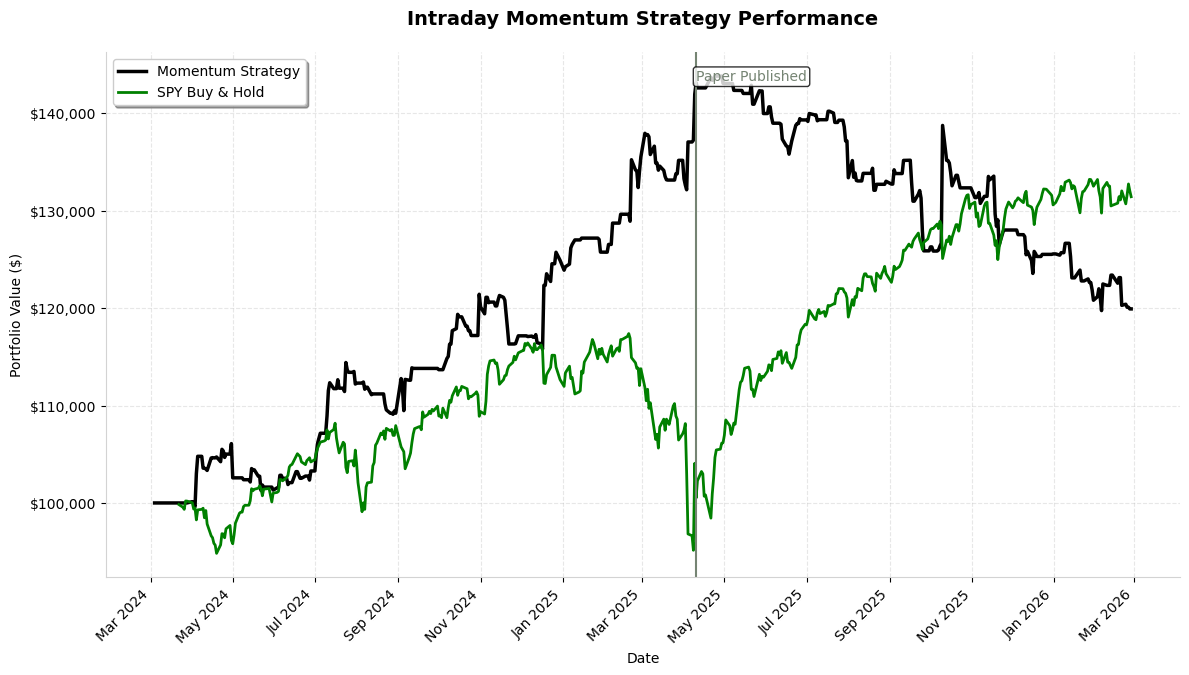


    STRATEGY PERFORMANCE SUMMARY
Total Return (%)              19.9
Annualized Return (%)          9.9
Annualized Volatility (%)     15.0
Sharpe Ratio                   0.7
Hit Ratio (%)                 46.3
Maximum Drawdown (%)          16.7
Alpha (%)                    12.52
Beta                         -0.13


In [207]:
# Running the backtest with the specified parameters in the research.

strat_base = run_backtest(df, df_daily, all_days)

commission = 0.0035

# Calculate AUM cumulative calculations
strat_base['AUM_SPX'] = AUM_0 * (1 + strat_base['ret_spy']).cumprod(skipna=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot momentum strategy and SPX buy & hold 
ax.plot(strat_base.index, strat_base['AUM'],
        label='Momentum Strategy',
        linewidth=2.5,
        color="#000000")

ax.plot(strat_base.index, strat_base['AUM_SPX'],
        label=f'{ticker} Buy & Hold',
        linewidth=2,
        color="#008000")

# Formatting 
ax.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')


# Research paper publication 
paper_date = pd.Timestamp('2025-04-10')
ax.axvline(x=paper_date, color='#758473', linewidth=1.5)
ax.text(paper_date, ax.get_ylim()[1] * 0.98,
        'Paper Published',
        color="#758473",
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',  alpha=0.8))

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('Portfolio Value ($)', fontweight='medium')
ax.set_xlabel('Date', fontweight='medium')

# Legend 
legend = ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')

ax.set_title('Intraday Momentum Strategy Performance',
            fontsize=14, fontweight='bold', pad=20)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('lightgray')
ax.spines['bottom'].set_color('lightgray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

# Calculate performance statistics
returns = strat_base['ret'].dropna()
spy_returns = strat_base['ret_spy'].dropna()

# Performance metrics
total_return = (np.prod(1 + returns) - 1) * 100
annualized_return = (np.prod(1 + returns) ** (252 / len(returns)) - 1) * 100
annualized_vol = returns.std() * np.sqrt(252) * 100
sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)
hit_ratio = (returns > 0).sum() / (returns.abs() > 0).sum() * 100

# Maximum drawdown
cumulative = strat_base['AUM'] / strat_base['AUM'].iloc[0]
rolling_max = cumulative.expanding().max()
drawdowns = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdowns.min() * -100

# Alpha and Beta
Y = returns
X = sm.add_constant(spy_returns)
model = sm.OLS(Y, X).fit()
alpha = model.params.const * 100 * 252
beta = model.params['ret_spy']

# Organized stats dictionary
stats = {
    'Total Return (%)': round(total_return, 1),
    'Annualized Return (%)': round(annualized_return, 1),
    'Annualized Volatility (%)': round(annualized_vol, 1),
    'Sharpe Ratio': round(sharpe_ratio, 2),
    'Hit Ratio (%)': round(hit_ratio, 1),
    'Maximum Drawdown (%)': round(max_drawdown, 1),
    'Alpha (%)': round(alpha, 2),
    'Beta': round(beta, 2)
}

# Clean output
print("\n" + "="*45)
print("    STRATEGY PERFORMANCE SUMMARY")
print("="*45)
for key, value in stats.items():
    print(f"{key:<25} {value:>8}")
print("="*45)

The strategy delivers solid a Sharpe ratio of 0.7 and an annualized return of 9.9%, though it underperforms the highly optimized dynamic sizing model from the research, which achieved a 1.33 Sharpe ratio and a 19.6% annualized return. However, our implementation demonstrates superior downside protection by restricting the maximum drawdown to just 16.7% compared to the research model's 25%, while maintaining a similarly negative beta (-0.13 versus -0.07) that confirms its effectiveness as an uncorrelated return stream.

Crucially, it is important to note that this recreation evaluates a completely different timeframe (March 2024 to March 2026) that includes data from after the study was made public. As illustrated in the  graph, the strategy's equity curve experiences a sharp and constant decline immediately following the paper's publication date. This drawdown indicates that the strategy stopped being profitable in live market conditions, which is highly likely due to alpha decay.

# 5. Backtesting the parameters

The backtesting framework employs a 70/30  split to evaluate the strategy's robustness, separating the data into an in-sample "training" period  and an out-of-sample "testing" period to simulate forward-looking performance. The parameter_search function executes a grid search across four key hyperparameters: the

*  Band Multiplier (0.5, 1.0, 1.5) to adjust Noise Area sensitivity 
*  Trade Frequency (15, 30, 60 minutes) to control execution timing 
*  Target Volatility ([0.01, 0.02, 0.03]) for dynamic sizing 
*  Maximum Leverage (2, 4, 6 ) to cap total exposure.  

We find the best Sharpe Ratio in the training data and validate it against the test set. This tells us if the strategy still actually works, or if the edge completely disappeared once the crowd found out about it.

Testing 81 parameter combinations on train set...

  Tested 10/81 combinations...
  Tested 20/81 combinations...
  Tested 30/81 combinations...
  Tested 40/81 combinations...
  Tested 50/81 combinations...
  Tested 60/81 combinations...
  Tested 70/81 combinations...
  Tested 80/81 combinations...

Best parameters (by sharpe on train set):
  band_mult      : 1.0
  trade_freq     : 30
  target_vol     : 0.02
  max_leverage   : 6
  sharpe         : 1.9894

Running best parameters on test set...
  Test sharpe: -1.2017


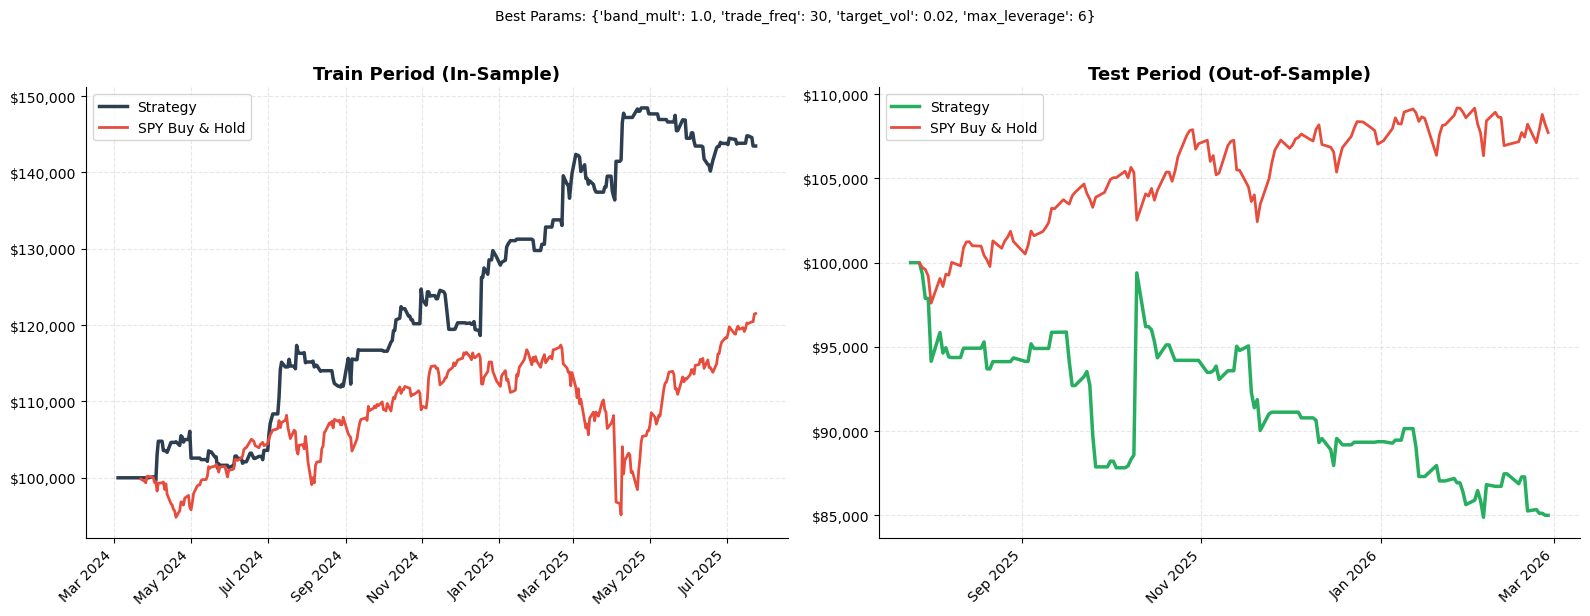

In [208]:


def parameter_search(df, df_daily, all_days, train_ratio=0.7, metric='sharpe'):


    #  Train/Test Split
    split_idx   = int(len(all_days) * train_ratio)
    train_days  = all_days[:split_idx]
    test_days   = all_days[split_idx:]
    
    
    # Filter df and df_daily to each split
    train_mask = df['day'].isin(train_days)
    test_mask  = df['day'].isin(test_days)
    df_train   = df[train_mask]
    df_test    = df[test_mask]

    df_daily_train = df_daily[df_daily.index.isin(train_days)]
    df_daily_test  = df_daily[df_daily.index.isin(test_days)]

    #  Parameter Grid 
    param_grid = {
        'band_mult'   : [0.5, 1.0, 1.5],
        'trade_freq'  : [15, 30, 60],
        'target_vol'  : [0.01, 0.02, 0.03],
        'max_leverage': [2, 4, 6],
    }

    #  Scoring function
    def score(strat, metric):
        returns = strat['ret'].dropna()
        if len(returns) == 0:
            return -np.inf
        if metric == 'sharpe':
            return returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else -np.inf
        elif metric == 'total_return':
            return (np.prod(1 + returns) - 1) * 100
        elif metric == 'max_drawdown':
            cumulative  = (1 + returns).cumprod()
            rolling_max = cumulative.expanding().max()
            drawdown    = ((cumulative - rolling_max) / rolling_max).min()
            return -drawdown  # negate so higher is better

    # Grid Search on Train Set
    keys   = list(param_grid.keys())
    values = list(param_grid.values())
    combos = list(product(*values))

    print(f"Testing {len(combos)} parameter combinations on train set...\n")


    train_results = []
    for i, combo in enumerate(combos):
        params = dict(zip(keys, combo))
        try:
            strat  = run_backtest(df_train, df_daily_train, train_days, **params)
            s      = score(strat, metric)
            train_results.append({**params, metric: round(s, 4)})
        except Exception as e:
            print(f"  Combo {i+1} failed: {e}")
            continue

        if (i + 1) % 10 == 0:
            print(f"  Tested {i+1}/{len(combos)} combinations...")

    # Find Best Parameters 
    results_df  = pd.DataFrame(train_results).sort_values(metric, ascending=False)
    best_params = results_df.iloc[0][keys].to_dict()
    best_params['band_mult']    = float(best_params['band_mult'])
    best_params['trade_freq']   = int(best_params['trade_freq'])
    best_params['target_vol']   = float(best_params['target_vol'])
    best_params['max_leverage'] = int(best_params['max_leverage'])

    print(f"\nBest parameters (by {metric} on train set):")
    for k, v in best_params.items():
        print(f"  {k:<15}: {v}")
    print(f"  {metric:<15}: {results_df.iloc[0][metric]}")

    # Evaluate Best Params on Test Set 
    print(f"\nRunning best parameters on test set...")
    test_strat  = run_backtest(df_test, df_daily_test, test_days, **best_params)
    test_score  = score(test_strat, metric)
    print(f"  Test {metric}: {round(test_score, 4)}")

    return best_params, results_df, test_strat


# Run the optimization 
best_params, results_df, test_strat = parameter_search(
    df, df_daily, all_days,
    train_ratio = 0.7,
    metric      = 'sharpe'
)

# Plot train vs test on best params
split_idx  = int(len(all_days) * 0.7)
train_days = all_days[:split_idx]
test_days  = all_days[split_idx:]

train_strat = run_backtest(
    df[df['day'].isin(train_days)],
    df_daily[df_daily.index.isin(train_days)],
    train_days, **best_params
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, strat, title, color in zip(
    axes,
    [train_strat, test_strat],
    ['Train Period (In-Sample)', 'Test Period (Out-of-Sample)'],
    ['#2C3E50', '#27AE60']
):
    strat['AUM_SPX'] = AUM_0 * (1 + strat['ret_spy']).cumprod(skipna=True)
    ax.plot(strat.index, strat['AUM'],     label='Strategy',      color=color,    linewidth=2.5)
    ax.plot(strat.index, strat['AUM_SPX'], label='SPY Buy & Hold', color='#E74C3C', linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle(f'Best Params: {best_params}', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


The results show a textbook case of curve-fitting. While the grid search found a parameter combination that looked fantastic in-sample achiving a Sharpe ratio of nearly 2.0 while pushing the maximum leverage up to 6—the strategy completely fell apart on unseen data, dropping to a  -1.20 Sharpe ratio out-of-sample. This massive drop-off indicates that the optimization process was likely just memorizing historical noise rather than capturing a robust edge. Ultimately, this contrast between train and test performance confirms our earlier observation that the intraday momentum alpha from the original paper has effectively dried up in current market conditions.

# 6. RSI based strategy

The RSI filter is added to improve the quality of trade signals by ensuring we only take momentum trades when the broader momentum condition is confirmed. Specifically, we only go long when RSI is above 60, indicating that recent gains outweigh recent losses, and only go short when RSI is below 40, filtering out false breakouts or mean-reverting markets. This should reduce the number of trades but should improve the hit ratio, as we avoid entering positions where the price has broken the band but lacks the sustained momentum needed to profit.

In [209]:
#  Check time period alignment 
df_rsi = pd.read_csv('spy_rsi.csv', index_col='caldt', parse_dates=True)
df_rsi.index = pd.to_datetime(df_rsi.index)
df_rsi['day'] = pd.to_datetime(df_rsi['day']).dt.date

# Find overlapping period
overlap_start = max(df.index.min(), df_rsi.index.min())
overlap_end   = min(df.index.max(), df_rsi.index.max())

# Trim both DataFrames to the overlapping period
df     = df[(df.index >= overlap_start)     & (df.index <= overlap_end)]
df_rsi = df_rsi[(df_rsi.index >= overlap_start) & (df_rsi.index <= overlap_end)]


if 'rsi' in df.columns:
    df = df.drop(columns=['rsi'])

#  Merge RSI into intraday df
df = df.merge(df_rsi[['rsi']], left_index=True, right_index=True, how='left')
df['rsi'] = df['rsi'].fillna(method='ffill')  # forward fill any missing bars



#  Rebuild daily groups and all_days after filter & merge 
df['day'] = df.index.date
all_days  = df['day'].unique()

# Rebuild df_daily from filtered df
daily_groups = df.groupby('day')
df_daily = daily_groups.agg(
    open=('open',   'first'),
    high=('high',   'max'),
    low=('low',     'min'),
    close=('close', 'last'),
    volume=('volume', 'sum')
).rename_axis('caldt')
df_daily.index = pd.to_datetime(df_daily.index)
df_daily['ret'] = df_daily['close'].pct_change()

/var/folders/d_/9b5my7752pgd4xd791kd55740000gn/T/ipykernel_84890/1987635632.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rsi'] = df['rsi'].fillna(method='ffill')  # forward fill any missing bars


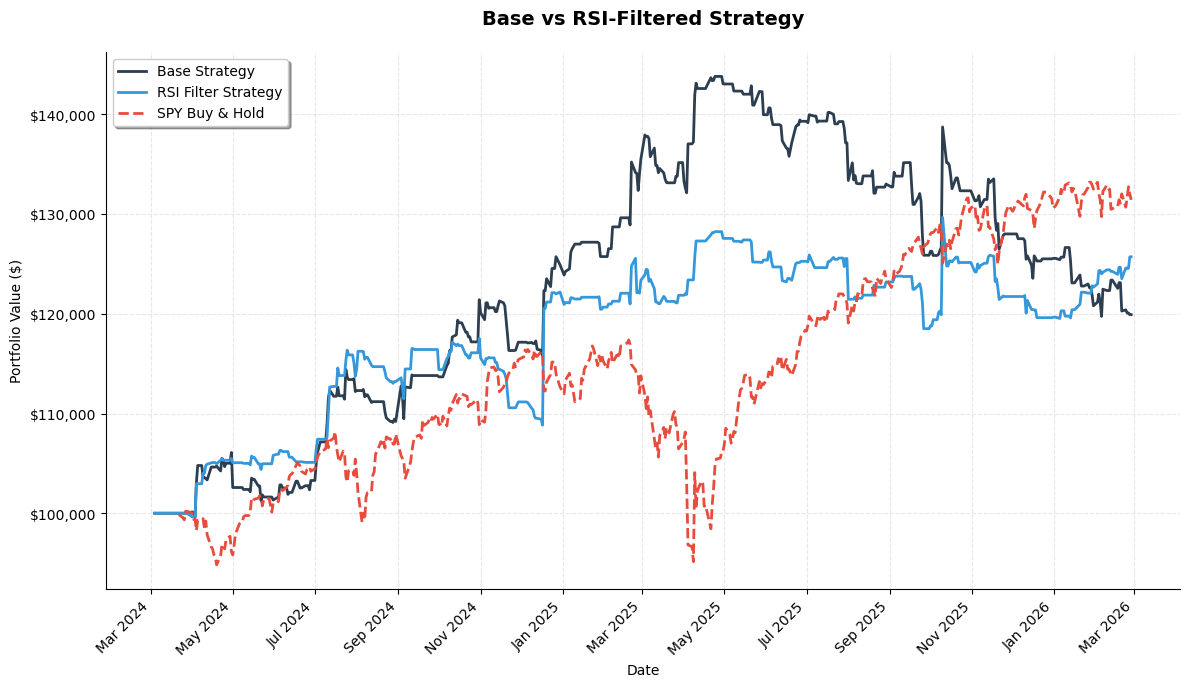

In [210]:
# Backtest function with RSI filter. Only takes long signals when RSI > rsi_long_threshold and short signals when RSI < rsi_short_threshold.

def run_backtest_rsi(
    df,
    df_daily,
    all_days,
    AUM_0              = 100000.0,
    commission         = 0.0035,
    min_comm_per_order = 0.35,
    band_mult          = 1,
    trade_freq         = 30,
    sizing_type        = "vol_target",
    target_vol         = 0.02,
    max_leverage       = 6,
    rsi_long_threshold  = 60,   # only go long  when RSI > this
    rsi_short_threshold = 40,   # only go short when RSI < this
):

    daily_groups = df.groupby('day')

    strat            = pd.DataFrame(index=all_days)
    strat['ret']     = np.nan
    strat['AUM']     = AUM_0
    strat['ret_spy'] = np.nan

    for d in range(1, len(all_days)):
        current_day = all_days[d]
        prev_day    = all_days[d - 1]

        if prev_day not in daily_groups.groups or current_day not in daily_groups.groups:
            continue

        prev_day_data    = daily_groups.get_group(prev_day)
        current_day_data = daily_groups.get_group(current_day)

        if 'sigma_open' in current_day_data.columns and current_day_data['sigma_open'].isna().all():
            continue

        prev_close           = prev_day_data['close'].iloc[-1]
        open_price           = current_day_data['open'].iloc[0]
        current_close_prices = current_day_data['close']
        spx_vol              = current_day_data['spy_dvol'].iloc[0]
        vwap                 = current_day_data['vwap']
        sigma_open           = current_day_data['sigma_open']
        rsi                  = current_day_data['rsi']

        UB = max(open_price, prev_close) * (1 + band_mult * sigma_open)
        LB = min(open_price, prev_close) * (1 - band_mult * sigma_open)

        #  Signals with RSI filter 
        signals = np.zeros_like(current_close_prices)
        signals[
            (current_close_prices > UB) &
            (current_close_prices > vwap) &
            (rsi > rsi_long_threshold)        # RSI confirms upward momentum
        ] = 1
        signals[
            (current_close_prices < LB) &
            (current_close_prices < vwap) &
            (rsi < rsi_short_threshold)       # RSI confirms downward momentum
        ] = -1

        #  Position sizing
        previous_aum = strat.loc[prev_day, 'AUM']
        if sizing_type == "vol_target":
            if math.isnan(spx_vol):
                shares = round(previous_aum / open_price * max_leverage)
            else:
                shares = round(previous_aum / open_price * min(target_vol / spx_vol, max_leverage))
        elif sizing_type == "full_notional":
            shares = round(previous_aum / open_price)

        #  Exposure with forward-fill 
        trade_indices = np.where(current_day_data["min_from_open"] % trade_freq == 0)[0]
        exposure  = np.full(len(current_day_data), np.nan)
        exposure[trade_indices] = signals[trade_indices]

        last_valid  = np.nan
        filled_values = []
        for value in exposure:
            if not np.isnan(value):
                last_valid = value
            if last_valid == 0:
                last_valid = np.nan
            filled_values.append(last_valid)

        exposure = pd.Series(filled_values, index=current_day_data.index).shift(1).fillna(0).values

        #  PnL 
        trades_count = np.sum(np.abs(np.diff(np.append(exposure, 0))))
        change_1m = current_close_prices.diff()
        gross_pnl = np.sum(exposure * change_1m) * shares
        commission_paid = trades_count * max(min_comm_per_order, commission * shares)
        net_pnl = gross_pnl - commission_paid

        strat.loc[current_day, 'AUM'] = previous_aum + net_pnl
        strat.loc[current_day, 'ret'] = net_pnl / previous_aum
        strat.loc[current_day, 'ret_spy'] = df_daily.loc[current_day, 'ret'] if current_day in df_daily.index else np.nan

    strat.index = pd.to_datetime(strat.index)
    return strat


#  Compare base vs RSI-filtered strategy 

strat_rsi  = run_backtest_rsi(df, df_daily, all_days,
                               rsi_long_threshold=60,
                               rsi_short_threshold=40)


strat_rsi['AUM_SPX']  = AUM_0 * (1 + strat_rsi['ret_spy']).cumprod(skipna=True)

#  Plot comparison 

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(strat_base.index, strat_base['AUM'], label='Base Strategy',     linewidth=2,   color='#2C3E50')
ax.plot(strat_rsi.index,  strat_rsi['AUM'],  label='RSI Filter Strategy', linewidth=2, color='#3498DB')
ax.plot(strat_base.index, strat_base['AUM_SPX'], label=f'{ticker} Buy & Hold', linewidth=2, color='#E74C3C', linestyle='--')

ax.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('Portfolio Value ($)', fontweight='medium')
ax.set_xlabel('Date', fontweight='medium')
ax.set_title('Base vs RSI-Filtered Strategy', fontsize=14, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend = ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [211]:

# Calculate performance statistics
returns     = strat_rsi['ret'].dropna()
spy_returns = strat_base['ret_spy'].dropna()

total_return       = (np.prod(1 + returns) - 1) * 100
annualized_return  = (np.prod(1 + returns) ** (252 / len(returns)) - 1) * 100
annualized_vol     = returns.std() * np.sqrt(252) * 100
sharpe_ratio       = returns.mean() / returns.std() * np.sqrt(252)
hit_ratio          = (returns > 0).sum() / (returns.abs() > 0).sum() * 100

cumulative   = strat_rsi['AUM'] / strat_rsi['AUM'].iloc[0]
rolling_max  = cumulative.expanding().max()
drawdowns    = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdowns.min() * -100

Y     = returns
X     = sm.add_constant(spy_returns)
model = sm.OLS(Y, X).fit()
alpha = model.params.const * 100 * 252
beta  = model.params['ret_spy']

stats_rsi = {
    'Total Return (%)':          round(total_return, 1),
    'Annualized Return (%)':     round(annualized_return, 1),
    'Annualized Volatility (%)': round(annualized_vol, 1),
    'Sharpe Ratio':              round(sharpe_ratio, 2),
    'Hit Ratio (%)':             round(hit_ratio, 1),
    'Maximum Drawdown (%)':      round(max_drawdown, 1),
    'Alpha (%)':                 round(alpha, 2),
    'Beta':                      round(beta, 2),
}


print(f"\n{'='*45}")
print(f"{'BASE STRATEGY PERFORMANCE SUMMARY':^45}")
print(f"{'='*45}")
for key, value in stats.items():
    print(f"  {key:<30} {value:>8}")
print(f"{'='*45}")

print(f"\n{'='*45}")
print(f"{'RSI STRATEGY PERFORMANCE SUMMARY':^45}")
print(f"{'='*45}")
for key, value in stats_rsi.items():
    print(f"  {key:<30} {value:>8}")
print(f"{'='*45}")


      BASE STRATEGY PERFORMANCE SUMMARY      
  Total Return (%)                   19.9
  Annualized Return (%)               9.9
  Annualized Volatility (%)          15.0
  Sharpe Ratio                        0.7
  Hit Ratio (%)                      46.3
  Maximum Drawdown (%)               16.7
  Alpha (%)                         12.52
  Beta                              -0.13

      RSI STRATEGY PERFORMANCE SUMMARY       
  Total Return (%)                   25.7
  Annualized Return (%)              12.7
  Annualized Volatility (%)          13.5
  Sharpe Ratio                       0.95
  Hit Ratio (%)                      50.2
  Maximum Drawdown (%)                7.8
  Alpha (%)                         14.65
  Beta                              -0.12


While the RSI-filtered strategy shows a modestly higher total return (25.7% vs 19.9%) and annualized return (12.7% vs 9.9%), the more important improvements are in risk-adjusted metrics, the Sharpe ratio improves from 0.70 to 0.95, volatility drops from 15.0% to 13.5%, and maximum drawdown is nearly halved from 16.7% to 7.8%. The RSI filter likely held back some of the strong pre-publication momentum gains, as the base strategy had a cleaner edge during that period. However, as visible in the plot, the RSI-filtered strategy demonstrates clear outperformance in the post-publication period where the raw momentum edge has decayed — suggesting the RSI filter adds value precisely in the noisier, more efficient market conditions that followed the paper's release. This makes the RSI-filtered strategy more robust.

Regarding further improvements in the futer the RSI threshold levels can be dinamically adjusted regarding the market conditions.